# Chlorophyll vs CDOM 412 (2018 Only) - Side By Side
This notebook reproduces the scatterplots for **2018 only**, including side-by-side subplots for Inside and Outside Upwelling.

In [2]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')

In [3]:
# Load the data
with open(r'E:\\satdata\\Custom\\yucatan_sst_chlor_cdomslope_ssl_bathy_2010-2019_v3.pkl', 'rb') as f:
    data = pickle.load(f)

df = data['data']
metadata = data['metadata']

if not isinstance(df.index, pd.DatetimeIndex):
    df = df.copy()
    df.index = pd.to_datetime(df.index, errors='coerce')
    df = df[~df.index.isna()]

lon_centers = np.array(metadata['lon_centers'])
lat_centers = np.array(metadata['lat_centers'])
if lon_centers.ndim == 1 and lat_centers.ndim == 1:
    lon_grid_2d, lat_grid_2d = np.meshgrid(lon_centers, lat_centers)
else:
    lon_grid_2d, lat_grid_2d = lon_centers, lat_centers

In [4]:
import warnings

# Calculate historical pixel-wise mean and std of SST for each month individually
sst_threshold_by_month = {}
with warnings.catch_warnings():
    warnings.simplefilter('ignore', category=RuntimeWarning)
    for m in range(1, 13):
        df_m = df[df.index.month == m]
        if not df_m.empty:
            m_sst = np.stack([np.array(x, dtype=float) for x in df_m['sst']])
            m_mean = np.nanmean(m_sst, axis=0)
            m_std = np.nanstd(m_sst, axis=0)
            sst_threshold_by_month[m] = m_mean - m_std

# Define upwelling zone bounding box
upwelling_lon_min, upwelling_lon_max = -92.20216, -85.61256
upwelling_lat_min, upwelling_lat_max = 19.57871, 22.86906

is_in_bbox = (lon_grid_2d >= upwelling_lon_min) & (lon_grid_2d <= upwelling_lon_max) & \
               (lat_grid_2d >= upwelling_lat_min) & (lat_grid_2d <= upwelling_lat_max)

In [5]:
# Build 2018-only point table
df_2018 = df[df.index.year == 2018]
print(f'Rows in 2018: {len(df_2018)}')

results_2018 = []

for date_idx, row in df_2018.iterrows():
    month = date_idx.month

    chlor = row.get('chlorophyll')
    cdom = row.get('cdom_412')
    sst = row.get('sst')

    if chlor is None or cdom is None or sst is None:
        continue
    if isinstance(chlor, float) and np.isnan(chlor):
        continue
    if isinstance(cdom, float) and np.isnan(cdom):
        continue
    if isinstance(sst, float) and np.isnan(sst):
        continue

    chlor_arr = np.array(chlor, dtype=float).flatten()
    cdom_arr = np.array(cdom, dtype=float).flatten()
    sst_arr = np.array(sst, dtype=float).flatten()
    
    # Inside upwelling: SST below the historical pixel-wise -1 std threshold AND inside the bounding box
    # Outside upwelling: inside the bounding box, but SST is NOT below the threshold
    bbox_arr = is_in_bbox.flatten()
    
    # Retrieve the properly localized -1 std threshold for the given month
    if month not in sst_threshold_by_month:
        continue
    threshold_arr = np.array(sst_threshold_by_month[month], dtype=float).flatten()
    
    # Filter only to pixels within the bounding box for this comparison (or remove bbox_arr if you want the whole map)
    # Using bbox_arr to limit analysis to the upwelling geographic zone
    is_upwelling_arr = (sst_arr < threshold_arr)

    valid = ~(np.isnan(chlor_arr) | np.isnan(cdom_arr) | np.isnan(sst_arr)) & bbox_arr
    if not np.any(valid):
        continue

    df_temp = pd.DataFrame({
        'chlor': chlor_arr[valid],
        'cdom412': cdom_arr[valid],
        'upwelling': is_upwelling_arr[valid],
        'month': month
    })
    results_2018.append(df_temp)

if len(results_2018) == 0:
    raise ValueError('No valid 2018 data points found.')

all_data_2018 = pd.concat(results_2018, ignore_index=True)
all_data_2018['Zone'] = all_data_2018['upwelling'].map({True: 'Inside Upwelling', False: 'Outside Upwelling'})
print(f'Total 2018 points: {len(all_data_2018)}')

Rows in 2018: 366
Total 2018 points: 3520955


May 2018 points: 50000


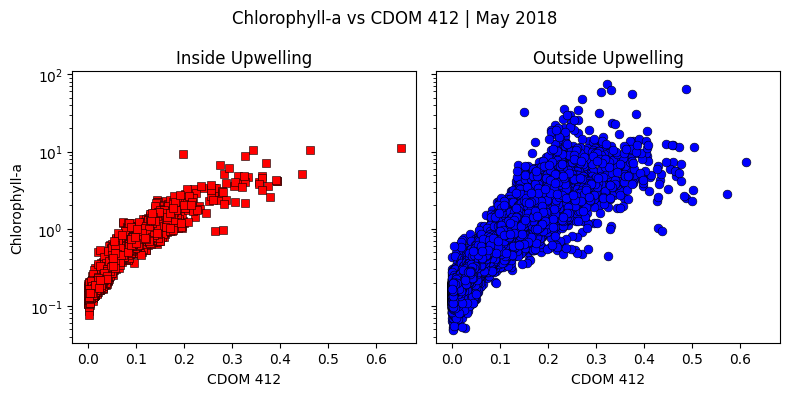

In [7]:
import calendar

# Generate one figure for each month in 2018
# month_order = range(1, 13)
month_order = [5]

for month in month_order:
    month_data = all_data_2018[all_data_2018['month'] == month].copy()
    
    max_points = 50000

    # Subsample to a maximum of 50,000 points per month for quicker plotting
    if len(month_data) > max_points:
        month_data = month_data.sample(n=max_points, random_state=42)
        
    month_name = calendar.month_name[month]
    print(f'{month_name} 2018 points: {len(month_data)}')

    if month_data.empty:
        print(f'No {month_name} 2018 data available after filtering.')
        continue

    fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharex=True, sharey=True)

    # Inside Upwelling Plot
    sns.scatterplot(
        ax=axes[0],
        data=month_data[month_data['Zone'] == 'Inside Upwelling'],
        x='cdom412',
        y='chlor',
        color='red',
        alpha=1,
        marker='s',
        s=40,
        linewidth=0.4,
        edgecolor='black'
    )
    axes[0].set_title('Inside Upwelling')
    axes[0].set_xlabel('CDOM 412')
    axes[0].set_ylabel('Chlorophyll-a')
    axes[0].set_yscale('log')

    # Outside Upwelling Plot
    sns.scatterplot(
        ax=axes[1],
        data=month_data[month_data['Zone'] == 'Outside Upwelling'],
        x='cdom412',
        y='chlor',
        color='blue',
        alpha=1,
        marker='o',
        s=40,
        linewidth=0.4,
        edgecolor='black'
    )
    
    axes[1].set_title('Outside Upwelling')
    axes[1].set_xlabel('CDOM 412')
    axes[1].set_yscale('log')

    fig.suptitle(f'Chlorophyll-a vs CDOM 412 | {month_name} 2018')
    plt.tight_layout()
    plt.show()